In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

import warnings
warnings.filterwarnings("ignore")

# Configure matplotlib settings
plt.rcParams.update({'figure.figsize': (9, 7), 'figure.dpi': 120})

In [6]:
# Load the datasets
train_data = pd.read_csv("train_data.csv")  
product_prices = pd.read_csv("product_prices.csv")  
date_to_week_id = pd.read_csv("date_to_week_id_map.csv") 

In [7]:
# Display sample data
print("Train Data Sample:\n", train_data.head())
print("\n\nProduct Prices Sample:\n", product_prices.head())
print("\n\nDate to Week ID Sample:\n", date_to_week_id.head())

Train Data Sample:
          date  product_identifier  department_identifier  \
0  2012-01-01                  74                     11   
1  2012-01-01                 337                     11   
2  2012-01-01                 423                     12   
3  2012-01-01                 432                     12   
4  2012-01-01                 581                     21   

          category_of_product  outlet        state  sales  
0                      others     111  Maharashtra      0  
1                      others     111  Maharashtra      1  
2                      others     111  Maharashtra      0  
3                      others     111  Maharashtra      0  
4  fast_moving_consumer_goods     111  Maharashtra      0  


Product Prices Sample:
    outlet  product_identifier  week_id  sell_price
0     111                  74       49        2.94
1     111                  74       50        2.94
2     111                  74       51        2.94
3     111                  74

In [8]:
# Perform the merging operations again
data_merged = train_data.merge(product_prices, on=['product_identifier', 'outlet'], how='left')
data_merged = data_merged.merge(date_to_week_id, left_on='date', right_on='date', how='left')

data_merged.head()

,date,product_identifier,department_identifier,category_of_product,outlet,state,sales,week_id_x,sell_price,week_id_y
0,2012-01-01,74,11,others,111,Maharashtra,0,49,2.94,49
1,2012-01-01,74,11,others,111,Maharashtra,0,50,2.94,49
2,2012-01-01,74,11,others,111,Maharashtra,0,51,2.94,49
3,2012-01-01,74,11,others,111,Maharashtra,0,52,2.94,49
4,2012-01-01,74,11,others,111,Maharashtra,0,53,2.94,49


In [9]:
# Aggregate sales by date for demand forecasting using the merged data
sales_data = data_merged.groupby('date')['sales'].sum().reset_index()

print(sales_data.head())

         date   sales
0  2012-01-01   77172
1  2012-01-02  101480
2  2012-01-03   73278
3  2012-01-04   82246
4  2012-01-05   80476


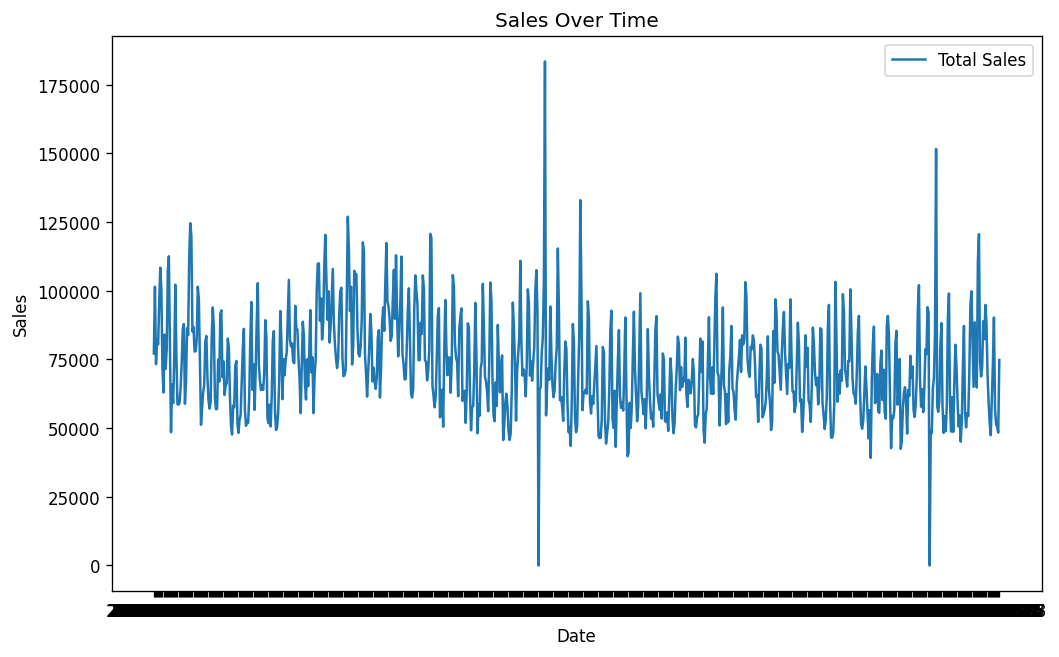

In [10]:
# Plot the sales data to visualize the trend
plt.figure(figsize=(10, 6))
plt.plot(sales_data['date'], sales_data['sales'], label='Total Sales')
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [12]:
# Test for stationarity using the Augmented Dickey-Fuller test
result = adfuller(sales_data['sales'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# If p-value > 0.05,
if result[1] > 0.05:
    sales_data['sales_diff'] = sales_data['sales'].diff().dropna()

ADF Statistic: -3.3126881562007204
p-value: 0.014320752832081007


In [13]:
# Fit the ARIMA model
model = ARIMA(sales_data['sales'].dropna(), order=(1, 1, 1))
arima_model = model.fit()

# Print the summary of the fitted model
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  790
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8724.019
Date:                Tue, 05 Nov 2024   AIC                          17454.038
Time:                        12:00:19   BIC                          17468.050
Sample:                             0   HQIC                         17459.424
                                - 790                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4704      0.025     18.847      0.000       0.422       0.519
ma.L1         -0.9774      0.011    -88.685      0.000      -0.999      -0.956
sigma2      2.802e+08   8.85e-12   3.16e+19      0.0

In [14]:
# Forecast sales for the next steps (e.g., next 12 time steps)
forecast_steps = 12
forecast = arima_model.forecast(steps=forecast_steps)
print("Forecasted Sales for Next 12 days:")
print(forecast)

Forecasted Sales for Next 12 days:
790    71791.832663
791    70371.070771
792    69702.709011
793    69388.295003
794    69240.386827
795    69170.807139
796    69138.075122
797    69122.677167
798    69115.433585
799    69112.026024
800    69110.423023
801    69109.668931
Name: predicted_mean, dtype: float64


In [15]:
# Evaluate model with Mean Squared Error on training data (for assessment purposes)
sales_data['sales_pred'] = arima_model.predict(start=0, end=len(sales_data) - 1)
mse = mean_squared_error(sales_data['sales'].dropna(), sales_data['sales_pred'])
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 238844114.8974686


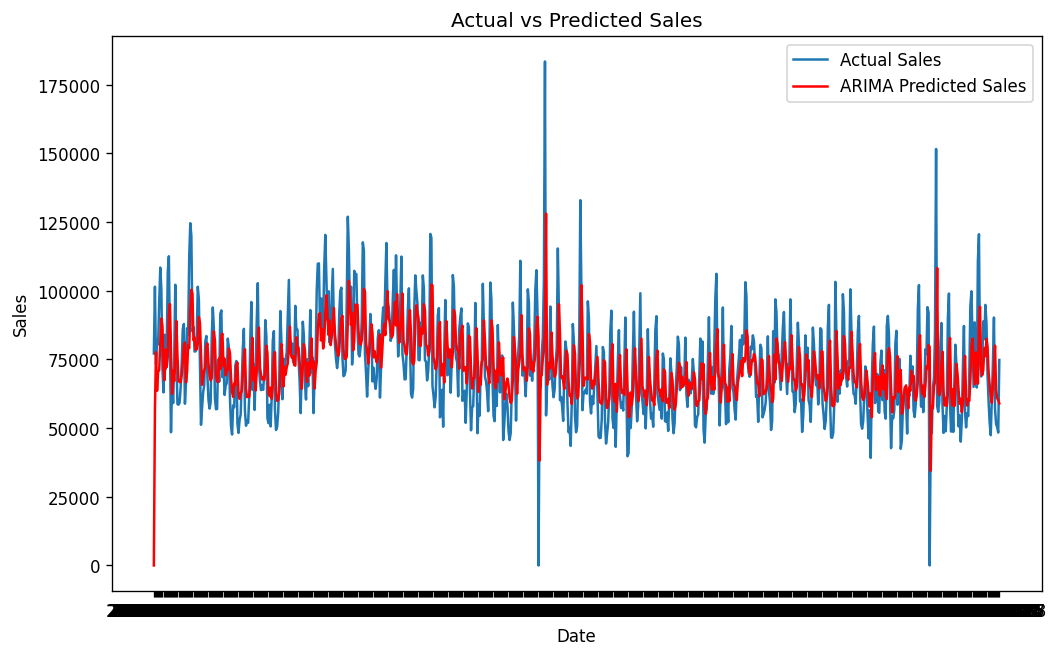

In [16]:
# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.plot(sales_data['date'], sales_data['sales'], label='Actual Sales')
plt.plot(sales_data['date'], sales_data['sales_pred'], label='ARIMA Predicted Sales', color='red')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [18]:
# Define train-test split for Out-of-Time Cross Validation
def train_test_split(time_series, test_size):
    """Splits time series data into train and test sets"""
    split_index = len(time_series) - test_size
    train, test = time_series[:split_index], time_series[split_index:]
    return train, test

# Function to perform Out-of-Time Cross Validation
def otc_cross_val(data, test_size=12, p_range=range(0, 3), d_range=range(0, 2), q_range=range(0, 3)):
    """Evaluates ARIMA models with various (p,d,q) parameters on cross-validation splits."""
    train, test = train_test_split(data, test_size)
    best_score, best_cfg = float("inf"), None
    
    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    model = ARIMA(train, order=(p, d, q))
                    model_fit = model.fit()
                    predictions = model_fit.forecast(steps=test_size)
                    mse = mean_squared_error(test, predictions)
                    
                    if mse < best_score:
                        best_score, best_cfg = mse, (p, d, q)
                    print(f"ARIMA{(p,d,q)} - MSE: {mse}")
                except Exception as e:
                    continue
    print(f"Best ARIMA parameters: {best_cfg} with MSE: {best_score}")
    return best_cfg, best_score

# Run the Out-of-Time Cross Validation function
best_params, best_mse = otc_cross_val(sales_data['sales'], test_size=12)
print(f"Optimal ARIMA parameters: {best_params} with MSE: {best_mse}")

ARIMA(0, 0, 0) - MSE: 290832120.7540103
ARIMA(0, 0, 1) - MSE: 292261654.197846
ARIMA(0, 0, 2) - MSE: 298463015.5918496
ARIMA(0, 1, 0) - MSE: 896890093.0
ARIMA(0, 1, 1) - MSE: 534061894.80582
ARIMA(0, 1, 2) - MSE: 336370715.31110555
ARIMA(1, 0, 0) - MSE: 325796565.8281551
ARIMA(1, 0, 1) - MSE: 302848350.5443999
ARIMA(1, 0, 2) - MSE: 300273131.39039576
ARIMA(1, 1, 0) - MSE: 922599203.0267524
ARIMA(1, 1, 1) - MSE: 304989557.6009843
ARIMA(1, 1, 2) - MSE: 310078109.190532
ARIMA(2, 0, 0) - MSE: 290194226.5369824
ARIMA(2, 0, 1) - MSE: 287044312.44930166
ARIMA(2, 0, 2) - MSE: 285267795.5963388
ARIMA(2, 1, 0) - MSE: 859342555.1513518
ARIMA(2, 1, 1) - MSE: 351430315.7137264
ARIMA(2, 1, 2) - MSE: 646257495.0977846
Best ARIMA parameters: (2, 0, 2) with MSE: 285267795.5963388
Optimal ARIMA parameters: (2, 0, 2) with MSE: 285267795.5963388


In [19]:
# Train final model with best parameters on full dataset
final_model = ARIMA(sales_data['sales'], order=best_params)
final_model_fit = final_model.fit()
print(final_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  790
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -8713.412
Date:                Tue, 05 Nov 2024   AIC                          17438.823
Time:                        12:00:31   BIC                          17466.855
Sample:                    01-01-2012   HQIC                         17449.598
                         - 02-28-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.251e+04    985.074     73.605      0.000    7.06e+04    7.44e+04
ar.L1          0.7177      0.354      2.030      0.042       0.025       1.411
ar.L2         -0.2802      0.114     -2.459      0.0

In [23]:
# Create Training and Test sets
train = sales_data['sales'][:590]
test = sales_data['sales'][590:]

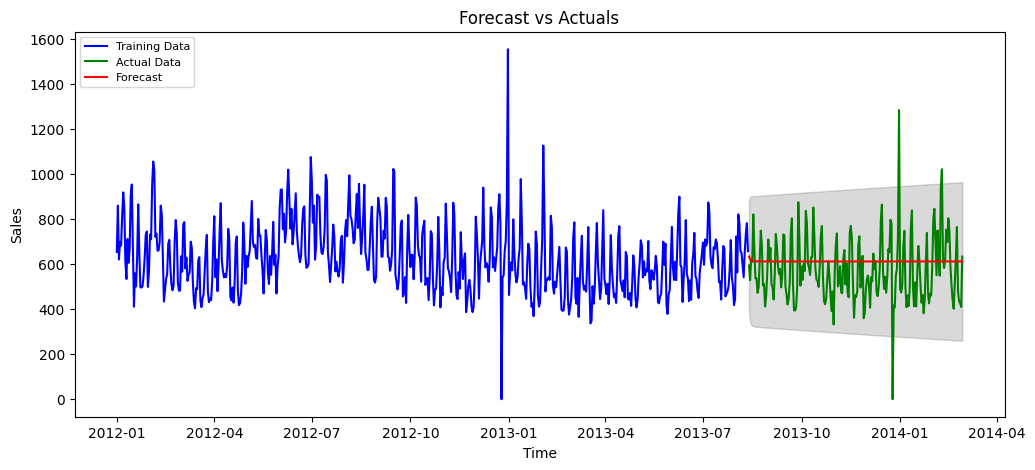

In [24]:
# Build the ARIMA Model with specified order
model = ARIMA(train, order=(1, 1, 1))
fitted = model.fit()

# Forecasting
forecast = fitted.get_forecast(steps=200)
fc = forecast.predicted_mean
conf = forecast.conf_int(alpha=0.05) 

# Convert forecast results to pandas Series
fc_series = pd.Series(fc, index=test.index[:len(fc)]) 
lower_series = pd.Series(conf.iloc[:, 0], index=test.index[:len(fc)])  
upper_series = pd.Series(conf.iloc[:, 1], index=test.index[:len(fc)]) 

# Plotting the results
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train, label='Training Data', color='blue')
plt.plot(test, label='Actual Data', color='green')
plt.plot(fc_series, label='Forecast', color='red')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend(loc='upper left', fontsize=8)
plt.show()

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  590
Model:                 ARIMA(3, 2, 1)   Log Likelihood               -3728.429
Date:                Tue, 05 Nov 2024   AIC                           7466.857
Time:                        12:00:31   BIC                           7488.741
Sample:                    01-01-2012   HQIC                          7475.384
                         - 08-12-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1383      0.025     -5.473      0.000      -0.188      -0.089
ar.L2         -0.2575      0.040     -6.410      0.000      -0.336      -0.179
ar.L3         -0.2226      0.041     -5.493      0.0

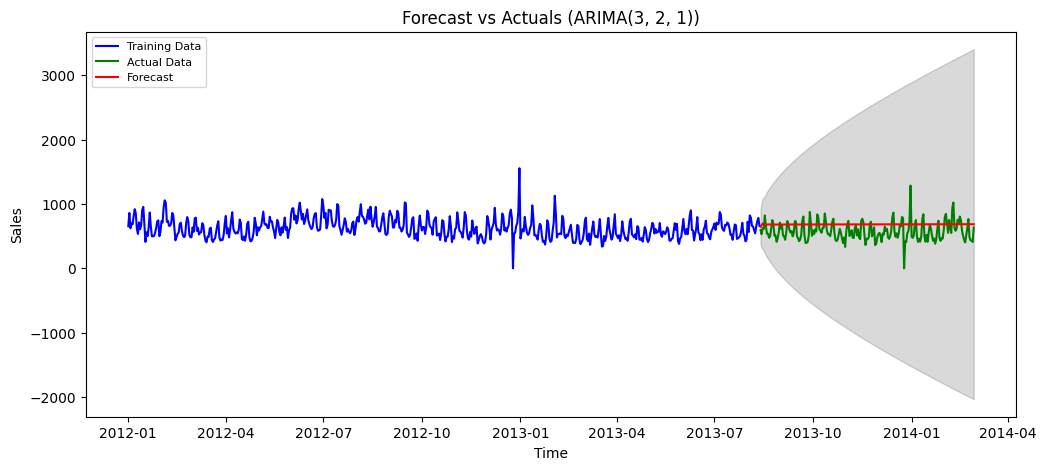

In [25]:
# Build another ARIMA Model with different order for comparison
model = ARIMA(train, order=(3, 2, 1))
fitted = model.fit()
print(fitted.summary())

# Forecast with the new model
forecast = fitted.get_forecast(steps=200)
fc = forecast.predicted_mean
conf = forecast.conf_int(alpha=0.05)

# Convert forecast results to pandas Series
fc_series = pd.Series(fc, index=test.index[:len(fc)])  # Forecast series
lower_series = pd.Series(conf.iloc[:, 0], index=test.index[:len(fc)])  # Lower CI
upper_series = pd.Series(conf.iloc[:, 1], index=test.index[:len(fc)])  # Upper CI

# Plotting the results
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(train, label='Training Data', color='blue')
plt.plot(test, label='Actual Data', color='green')
plt.plot(fc_series, label='Forecast', color='red')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=.15)
plt.title('Forecast vs Actuals (ARIMA(3, 2, 1))')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [26]:
# Define forecast accuracy metrics
def forecast_accuracy(forecast, actual):
    # Mean Absolute Percentage Error (MAPE)
    mape = np.mean(np.abs(forecast - actual) / np.abs(actual)) * 100  
    # Mean Error (ME)
    me = np.mean(forecast - actual)                                
    # Mean Absolute Error (MAE)
    mae = np.mean(np.abs(forecast - actual))                       
    # Mean Percentage Error (MPE)
    mpe = np.mean((forecast - actual) / actual) * 100              
    # Root Mean Squared Error (RMSE)
    rmse = np.sqrt(np.mean((forecast - actual) ** 2))              
    # Correlation Coefficient between forecast and actual
    corr = np.corrcoef(forecast, actual)[0, 1]                    
    # Min-Max Error
    mins = np.amin(np.vstack([forecast, actual]), axis=0)
    maxs = np.amax(np.vstack([forecast, actual]), axis=0)
    minmax = 1 - np.mean(mins / maxs)                              
    # Autocorrelation of the residuals at lag 1
    residuals = forecast - actual
    acf1 = acf(residuals, fft=False)[1] if len(residuals) > 1 else np.nan 

    # Return dictionary of metrics
    return {
        'mape': mape, 'me': me, 'mae': mae,
        'mpe': mpe, 'rmse': rmse, 'acf1': acf1,
        'corr': corr, 'minmax': minmax
    }

# Example usage
accuracy_metrics = forecast_accuracy(fc_series.values, test.values)
print(accuracy_metrics)


{'mape': inf, 'me': 106.15864419102574, 'mae': 150.87070493240125, 'mpe': inf, 'rmse': 178.66269309640333, 'acf1': 0.38835154687140355, 'corr': 0.005159079672436158, 'minmax': 0.2144627560914707}


In [27]:
!pip install pmdarima

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=10127.902, Time=0.46 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12435.313, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=10135.396, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=11561.384, Time=0.23 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=10135.215, Time=0.77 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=9892.036, Time=0.81 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=11081.683, Time=0.66 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=9887.940, Time=1.10 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.85 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.53 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=9885.474, Time=0.54 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=10813.427, Time=0.31 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=9897.656, Time=0.62 sec

Best model:  ARIMA(1,0,3)(0,0,0)[0]          
Total fit time: 6.910 seconds
                         

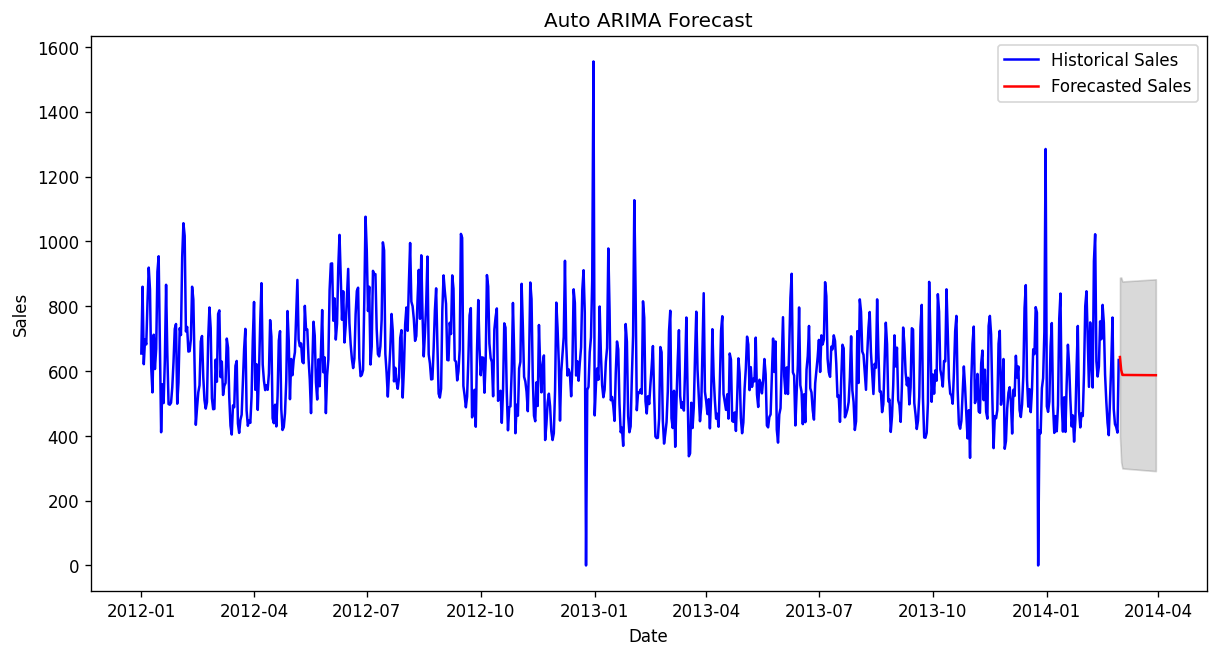

In [29]:
import pmdarima as pm

# Setting up Auto ARIMA
model = pm.auto_arima(
    sales_data['sales'],
    start_p=1, start_q=1,
    test='adf',             
    max_p=3, max_q=3,     
    m=1,              
    d=None,                
    seasonal=False,   
    start_P=0,           
    D=0, 
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True 
)

# Display the summary of the best model
print(model.summary())

# Fit the best ARIMA model found
fitted_model = model.fit(sales_data['sales'])

# Forecasting for the next 30 steps
forecast_steps = 30
forecast, conf_int = model.predict(n_periods=forecast_steps, return_conf_int=True)

# Generate future date range for forecast
forecast_dates = pd.date_range(sales_data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)

# Plot the forecast
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(sales_data.index, sales_data['sales'], label='Historical Sales', color='blue')
plt.plot(forecast_dates, forecast, label='Forecasted Sales', color='red')
plt.fill_between(forecast_dates, conf_int[:, 0], conf_int[:, 1], color='k', alpha=0.15)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Auto ARIMA Forecast')
plt.legend()
plt.show()

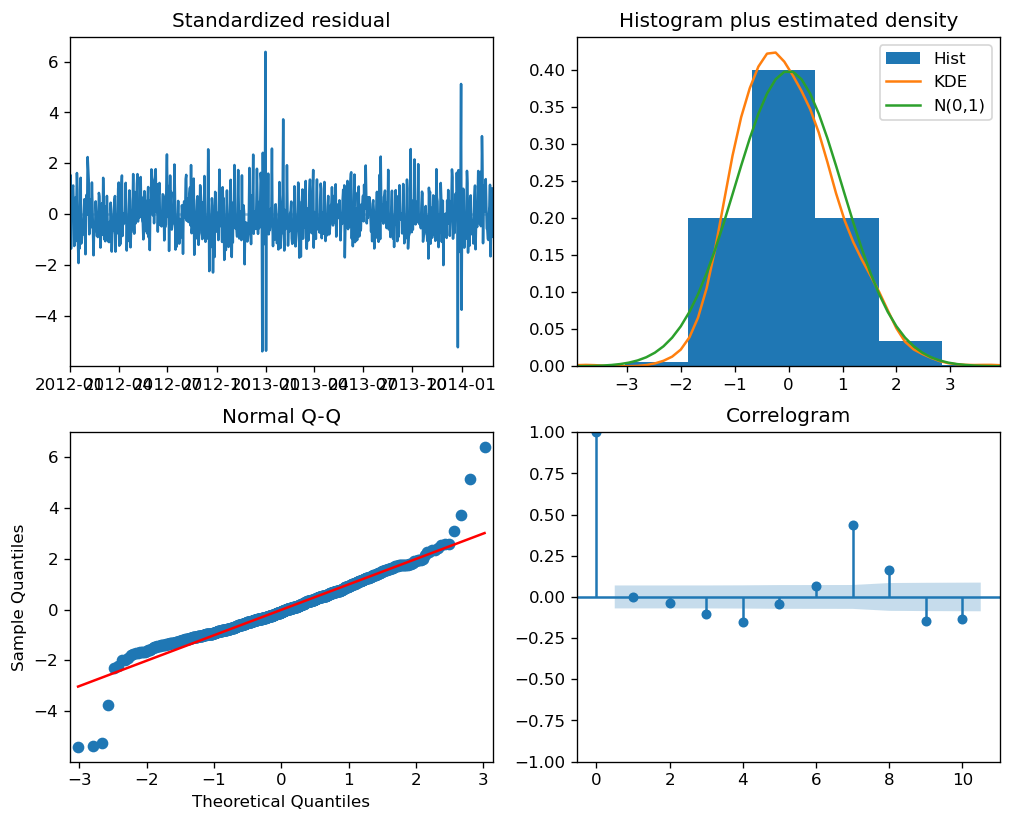

In [26]:
model.plot_diagnostics(figsize=(10,8))
plt.show()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=10127.902, Time=0.29 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=12435.313, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=10135.396, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=11561.384, Time=0.32 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=10135.215, Time=0.90 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=9892.036, Time=1.14 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=11081.683, Time=0.88 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=9887.940, Time=1.98 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=3.88 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=4.10 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=9885.474, Time=2.06 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=10813.427, Time=1.65 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=9897.656, Time=3.24 sec

Best model:  ARIMA(1,0,3)(0,0,0)[0]          
Total fit time: 20.617 seconds


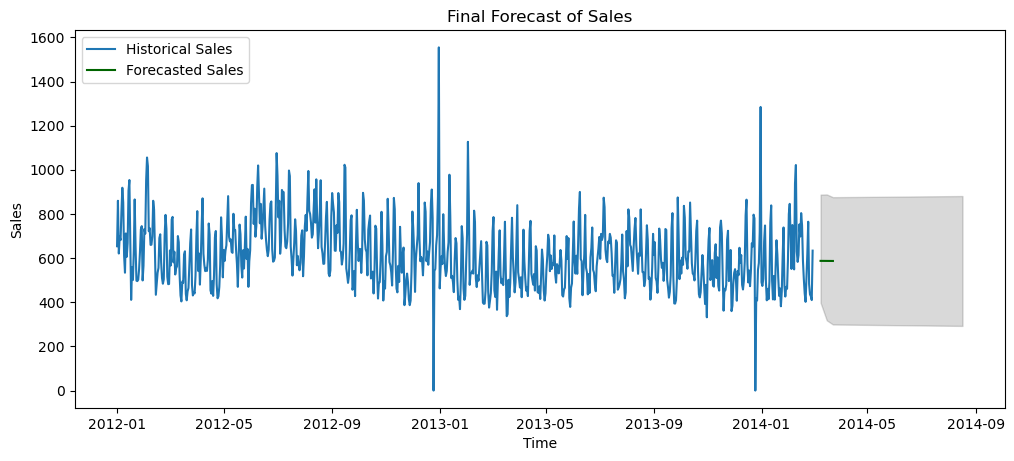

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima

# Fit the Auto ARIMA model
model = auto_arima(sales_data['sales'], start_p=1, start_q=1,
                   test='adf', max_p=3, max_q=3, m=1, d=0,
                   seasonal=False, trace=True, error_action='ignore',
                   suppress_warnings=True, stepwise=True)

# Forecast
n_periods = 24
fc, confint = model.predict(n_periods=n_periods, return_conf_int=True)

# Generate forecast index
last_date = sales_data.index[-1]
index_of_fc = pd.date_range(start=last_date, periods=n_periods+1, freq='W')[1:]

# Convert forecast results to pandas Series
fc_series = pd.Series(fc, index=index_of_fc)
lower_series = pd.Series(confint[:, 0], index=index_of_fc)
upper_series = pd.Series(confint[:, 1], index=index_of_fc)

# Plotting
plt.figure(figsize=(12, 5), dpi=100)
plt.plot(sales_data['sales'], label='Historical Sales')
plt.plot(fc_series, color='darkgreen', label='Forecasted Sales')
plt.fill_between(lower_series.index, lower_series, upper_series, 
                 color='k', alpha=0.15)

plt.title("Final Forecast of Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend(loc='upper left')
plt.show()

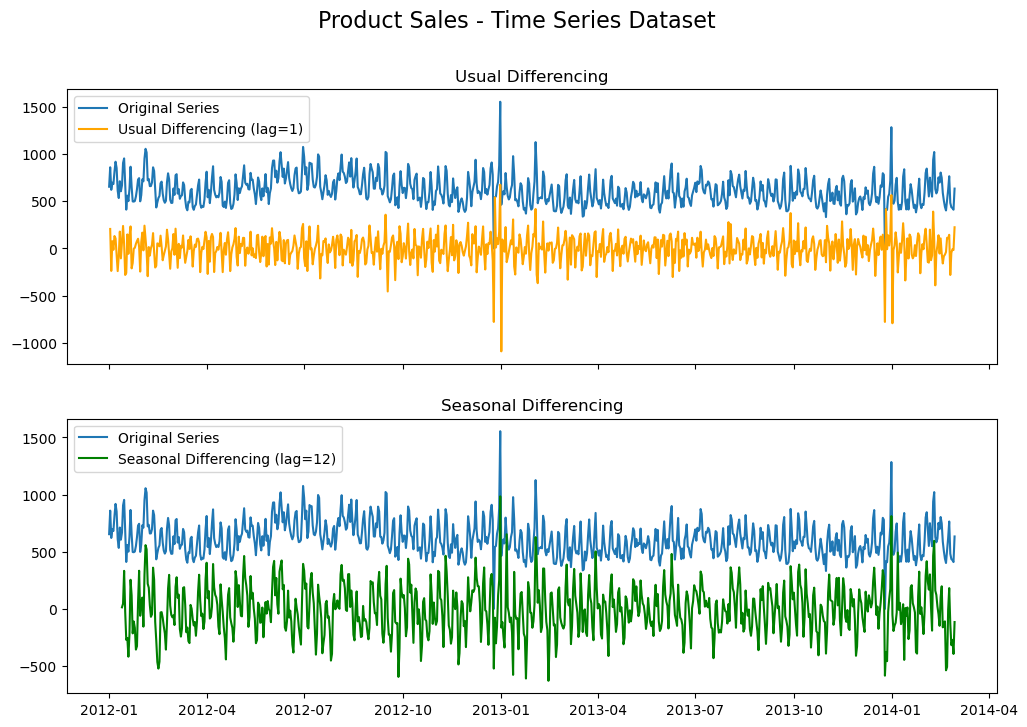

In [29]:
import matplotlib.pyplot as plt

data = sales_data['sales']

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 8), dpi=100, sharex=True)

# Usual Differencing (lag=1)
axes[0].plot(data, label='Original Series')
axes[0].plot(data.diff(1), label='Usual Differencing (lag=1)', color='orange')
axes[0].set_title('Usual Differencing')
axes[0].legend(loc='upper left', fontsize=10)

# Seasonal Differencing (lag=12)
axes[1].plot(data, label='Original Series')
axes[1].plot(data.diff(12), label='Seasonal Differencing (lag=12)', color='green')
axes[1].set_title('Seasonal Differencing')
axes[1].legend(loc='upper left', fontsize=10)

plt.suptitle('Product Sales - Time Series Dataset', fontsize=16)
plt.show()

In [30]:
# Adjust m (seasonal length) based on your data frequency
auto_model = pm.auto_arima(sales_data['sales'], start_p=1, start_q=1,
                           test='adf',
                           max_p=3, max_q=3,
                           m=12, 
                           seasonal=True,
                           start_P=0, max_P=3, max_D=2, max_Q=3,
                           trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=9903.751, Time=0.90 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=10178.355, Time=0.07 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=9924.608, Time=3.50 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=9924.236, Time=1.97 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=12435.313, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=9906.989, Time=0.46 sec
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=9902.599, Time=5.36 sec
 ARIMA(1,0,1)(1,0,0)[12] intercept   : AIC=9902.340, Time=4.93 sec
 ARIMA(1,0,1)(2,0,0)[12] intercept   : AIC=9894.671, Time=10.17 sec
 ARIMA(1,0,1)(3,0,0)[12] intercept   : AIC=9865.242, Time=14.99 sec
 ARIMA(1,0,1)(3,0,1)[12] intercept   : AIC=9859.805, Time=22.10 sec
 ARIMA(1,0,1)(2,0,1)[12] intercept   : AIC=9897.846, Time=10.99 sec
 ARIMA(1,0,1)(3,0,2)[12] intercept   : AIC=inf, Time=24.34 sec
 ARIMA(1,0,1)(2,0,2)[12] intercept   : AIC=9890.021, Time=13.58 sec
 ARIMA(0,0,1)(3,

In [31]:
# Experiment with slightly different values for (p, d, q) and (P, D, Q, s) to see if it improves the fit
model = SARIMAX(sales_data['sales'], 
                order=(1,1,1),  # Modify p, d, q as needed based on analysis
                seasonal_order=(1,1,1,12),  # Modify P, D, Q, s as appropriate
                enforce_stationarity=False, 
                enforce_invertibility=False)

sarima_result = model.fit(disp=False)
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                  790
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -4802.244
Date:                            Sun, 03 Nov 2024   AIC                           9614.487
Time:                                    22:34:37   BIC                           9637.673
Sample:                                01-01-2012   HQIC                          9623.414
                                     - 02-28-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4552      0.024     18.980      0.000       0.408       0.502
ma.L1         -0.9675      0.013   

In [43]:
print("Data Summary:\n", data.describe())
print("Data Null Values:\n", data.isnull().sum())

Data Summary:
 count     790.000000
mean      614.459494
std       151.587042
min         0.000000
25%       504.000000
50%       595.000000
75%       707.750000
max      1555.000000
Name: sales, dtype: float64
Data Null Values:
 0


In [44]:
import statsmodels.api as sm

# Re-fit the model
model = sm.tsa.statespace.SARIMAX(data, order=(2, 0, 1), seasonal_order=(3, 0, 3, 12), enforce_stationarity=False, enforce_invertibility=False)
fitted_model = model.fit(disp=False)

# Print summary to inspect the model fit
print(fitted_model.summary())

                                         SARIMAX Results                                          
Dep. Variable:                                      sales   No. Observations:                  790
Model:             SARIMAX(2, 0, 1)x(3, 0, [1, 2, 3], 12)   Log Likelihood               -4680.549
Date:                                    Sun, 03 Nov 2024   AIC                           9381.098
Time:                                            22:46:46   BIC                           9427.325
Sample:                                        01-01-2012   HQIC                          9398.908
                                             - 02-28-2014                                         
Covariance Type:                                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2854      0.047     27.486      0

In [45]:
test_model = sm.tsa.ARIMA(data, order=(1, 1, 1))
test_fitted = test_model.fit()
test_forecast = test_fitted.forecast(steps=n_periods)

print("Test Forecast:\n", test_forecast)

Test Forecast:
 2014-03-01    608.228885
2014-03-02    596.329966
2014-03-03    590.836053
2014-03-04    588.299429
2014-03-05    587.128231
2014-03-06    586.587470
2014-03-07    586.337793
2014-03-08    586.222513
2014-03-09    586.169287
2014-03-10    586.144711
2014-03-11    586.133364
2014-03-12    586.128125
2014-03-13    586.125706
2014-03-14    586.124590
2014-03-15    586.124074
2014-03-16    586.123836
2014-03-17    586.123726
2014-03-18    586.123675
2014-03-19    586.123652
2014-03-20    586.123641
2014-03-21    586.123636
2014-03-22    586.123634
2014-03-23    586.123633
2014-03-24    586.123632
2014-03-25    586.123632
Freq: D, Name: predicted_mean, dtype: float64


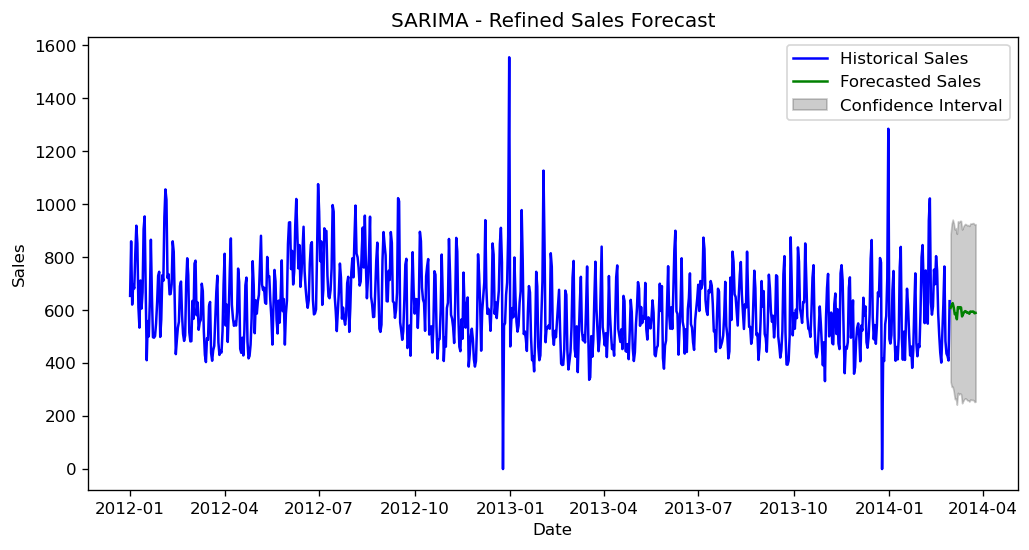

In [49]:
import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(data, order=(2, 0, 1), seasonal_order=(1, 0, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
fitted_model = model.fit(disp=False)

# Forecast
n_periods = 25
forecast = fitted_model.get_forecast(steps=n_periods)
fitted_series = forecast.predicted_mean
conf_int = forecast.conf_int()
lower_series = conf_int.iloc[:, 0]
upper_series = conf_int.iloc[:, 1]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(data, color='blue', label='Historical Sales')
plt.plot(fitted_series.index, fitted_series, color='green', label='Forecasted Sales')
plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=0.2, label='Confidence Interval')
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("SARIMA - Refined Sales Forecast")
plt.legend()
plt.show()

In [51]:
def make_stationary(series):
    result = adfuller(series)
    return series.diff().dropna() if result[1] > 0.05 else series

In [57]:
# Check if the data is stationary
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    return result[1]  # Return p-value

# If sales_data is not stationary, make it stationary by differencing
sales_data = train_data.groupby('date')['sales'].sum().reset_index()
sales_data['date'] = pd.to_datetime(sales_data['date'])
sales_data.set_index('date', inplace=True)

p_value = check_stationarity(sales_data['sales'])
if p_value > 0.05:
    sales_data['sales_diff'] = sales_data['sales'].diff().dropna()
    print("Data differenced once.")
else:
    print("Data is stationary.")

# Using Auto ARIMA to find the best model parameters
auto_arima_model = auto_arima(
    sales_data['sales'].dropna(),
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    seasonal=True,
    m=12,
    d=1, D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_arima_model.summary())

# Fitting the best SARIMA model suggested by auto_arima
sarima_model = SARIMAX(
    sales_data['sales'], 
    order=auto_arima_model.order,
    seasonal_order=auto_arima_model.seasonal_order
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

ADF Statistic: -3.3126881562007218
p-value: 0.014320752832080948
Data is stationary.
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=2.12 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=10609.617, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=10420.037, Time=0.32 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.83 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=10609.686, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=10158.875, Time=0.96 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.46 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.13 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=10178.275, Time=0.27 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=10052.838, Time=1.83 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=10376.322, Time=0.51 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=3.07 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=1.46 sec
 ARIMA(3,1,0)(2,1,0)[12]

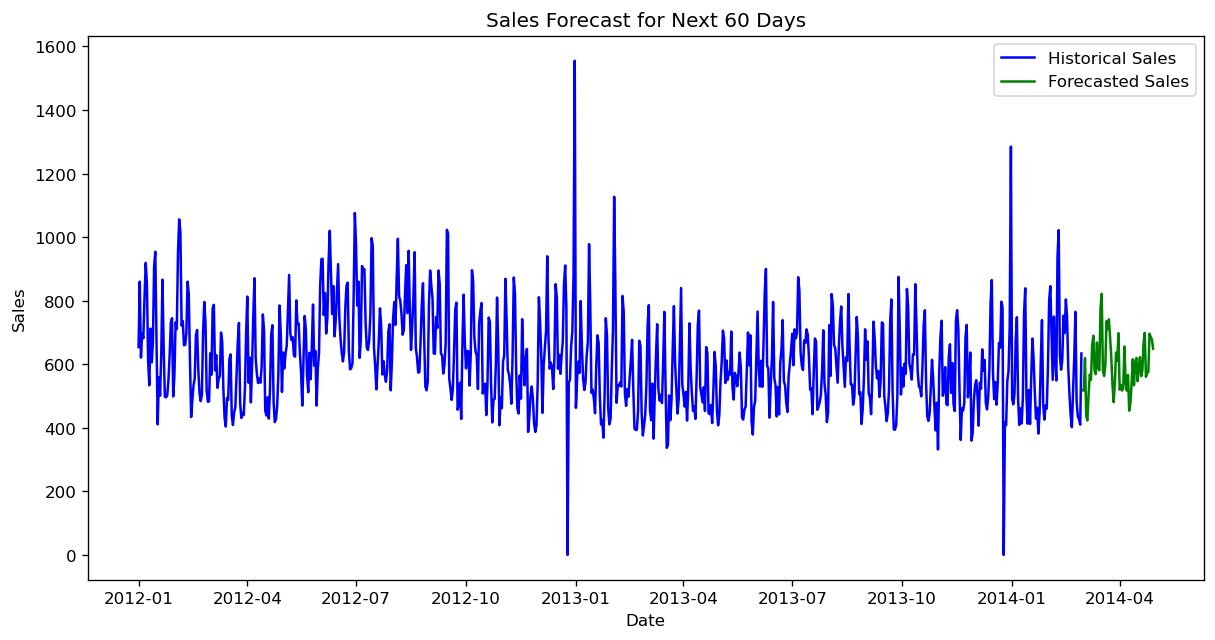

In [64]:
# Forecasting for the next 60 time periods
forecast_steps = 60
forecast = sarima_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Generate future date range for forecast
forecast_dates = pd.date_range(sales_data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

# Plot historical data with forecast
plt.figure(figsize=(12, 6))
plt.plot(sales_data.index, sales_data['sales'], label='Historical Sales', color='blue')
plt.plot(forecast_dates, forecast_mean, label='Forecasted Sales', color='green')
# plt.fill_between(forecast_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=0.05)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Forecast for Next 60 Days')
plt.legend()
plt.show()

In [31]:
from pmdarima import auto_arima
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

sales_data = data_merged.groupby('date')['sales'].sum().reset_index()
sales_data['date'] = pd.to_datetime(sales_data['date'])
sales_data.set_index('date', inplace=True)

In [33]:
# SARIMA Model
auto_arima_model = auto_arima(
    sales_data['sales'].dropna(),
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    seasonal=True,
    m=12,
    d=1, D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(auto_arima_model.summary())

# Fit SARIMA model
sarima_model = SARIMAX(
    sales_data['sales'],
    order=auto_arima_model.order,
    seasonal_order=auto_arima_model.seasonal_order
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=1.42 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=18023.369, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=17854.485, Time=0.47 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.07 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=18023.309, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=17688.325, Time=0.70 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=17596.394, Time=0.98 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.37 sec
 ARIMA(1,1,0)(2,1,2)[12]             : AIC=inf, Time=1.45 sec
 ARIMA(1,1,0)(1,1,2)[12]             : AIC=inf, Time=1.08 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=inf, Time=0.99 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=17518.832, Time=2.06 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=0.61 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=17600.505, Time=0.84 sec
 ARIMA(2,1,0)(2,1,2)[12]             : AIC=1751

In [60]:
# Forecasting with SARIMA model for the next 60 time periods
forecast_steps = 60
forecast_sarima = sarima_fit.get_forecast(steps=forecast_steps)
forecast_mean_sarima = forecast_sarima.predicted_mean
forecast_ci_sarima = forecast_sarima.conf_int()

# Calculate SARIMA residuals
residuals = sales_data['sales'] - sarima_fit.fittedvalues

In [44]:
# Normalize the residuals for LSTM
scaler = MinMaxScaler()
residuals_scaled = scaler.fit_transform(residuals.dropna().values.reshape(-1, 1))

# Prepare data for LSTM
X, y = [], []
lookback = 12
for i in range(len(residuals_scaled) - lookback):
    X.append(residuals_scaled[i:i + lookback])
    y.append(residuals_scaled[i + lookback])
X, y = np.array(X), np.array(y)

In [45]:
# Build LSTM model
lstm_model = Sequential([ 
    LSTM(50, activation='relu', input_shape=(X.shape[1], X.shape[2])), 
    Dense(1) 
])
lstm_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train LSTM model
lstm_model.fit(X, y, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0327
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0077
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0083
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0073
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0092
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0079
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0078
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0093
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0097
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0093
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0080
Epoch 12/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0080
Epoch 13/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0083
Epoch 14/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0085
Epoch 15/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0085
Epoch 16/50
49/49 ━

In [46]:
# Forecast with LSTM model
lstm_input = residuals_scaled[-lookback:]  # Last window of residuals for LSTM prediction
lstm_input = lstm_input.reshape((1, lookback, 1))

lstm_forecasts = []
for _ in range(forecast_steps):
    lstm_pred = lstm_model.predict(lstm_input)
    lstm_forecasts.append(lstm_pred[0, 0])
    # Update the input sequence with the new forecast
    lstm_input = np.append(lstm_input[:, 1:, :], lstm_pred.reshape(1, 1, 1), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━

In [47]:
print("lstm_input shape:", lstm_input.shape)
print("lstm_pred shape:", lstm_pred.shape)

lstm_input shape: (1, 12, 1)
lstm_pred shape: (1, 1)


In [61]:
# Inverse scale LSTM forecasts
lstm_forecasts = scaler.inverse_transform(np.array(lstm_forecasts).reshape(-1, 1)).flatten()

# Combine SARIMA and LSTM forecasts
combined_forecast = forecast_mean_sarima + lstm_forecasts

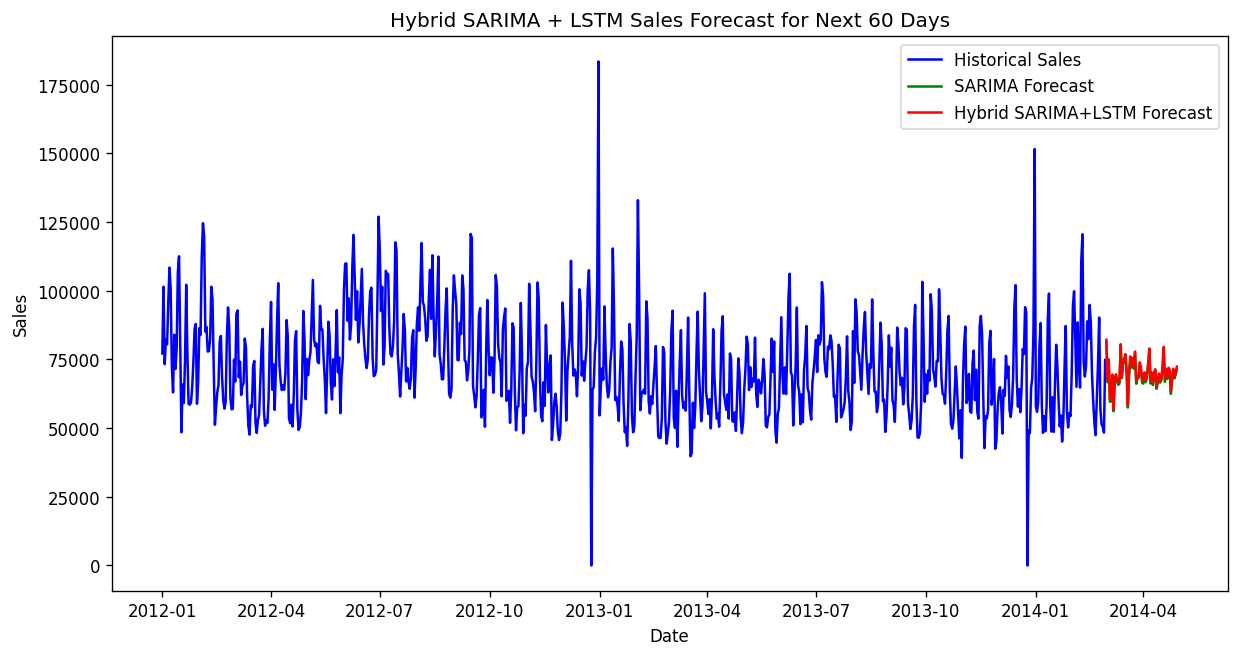

In [49]:
forecast_dates = pd.date_range(sales_data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='D')

# Plot historical data, SARIMA forecast, and combined forecast
plt.figure(figsize=(12, 6))
plt.plot(sales_data.index, sales_data['sales'], label='Historical Sales', color='blue')
plt.plot(forecast_dates, forecast_mean_sarima, label='SARIMA Forecast', color='green')
plt.plot(forecast_dates, combined_forecast, label='Hybrid SARIMA+LSTM Forecast', color='red')
# plt.fill_between(forecast_dates, forecast_ci_sarima.iloc[:, 0] + lstm_forecasts, forecast_ci_sarima.iloc[:, 1] + lstm_forecasts, color='k', alpha=0.05, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Hybrid SARIMA + LSTM Sales Forecast for Next 60 Days')
plt.legend()
plt.show()

In [50]:
print("Shape of residuals (before scaling):", residuals.shape)
print("Length of LSTM input data (X):", len(X))
print("Length of LSTM output data (y):", len(y))

# After inverse scaling
print("Length of LSTM forecasts:", len(lstm_forecasts))
print("Length of combined forecast:", len(combined_forecast))

Shape of residuals (before scaling): (790,)
Length of LSTM input data (X): 778
Length of LSTM output data (y): 778
Length of LSTM forecasts: 60
Length of combined forecast: 60


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

true_values = sales_data['sales'][-forecast_steps:]  # last actual values
mae = mean_absolute_error(true_values, combined_forecast)
mse = mean_squared_error(true_values, combined_forecast)
rmse = sqrt(mse)

print(f'MAE: {mae}, MSE: {mse}, RMSE: {rmse}')

MAE: 16822.75957651106, MSE: 427321711.62704074, RMSE: 20671.76121251019


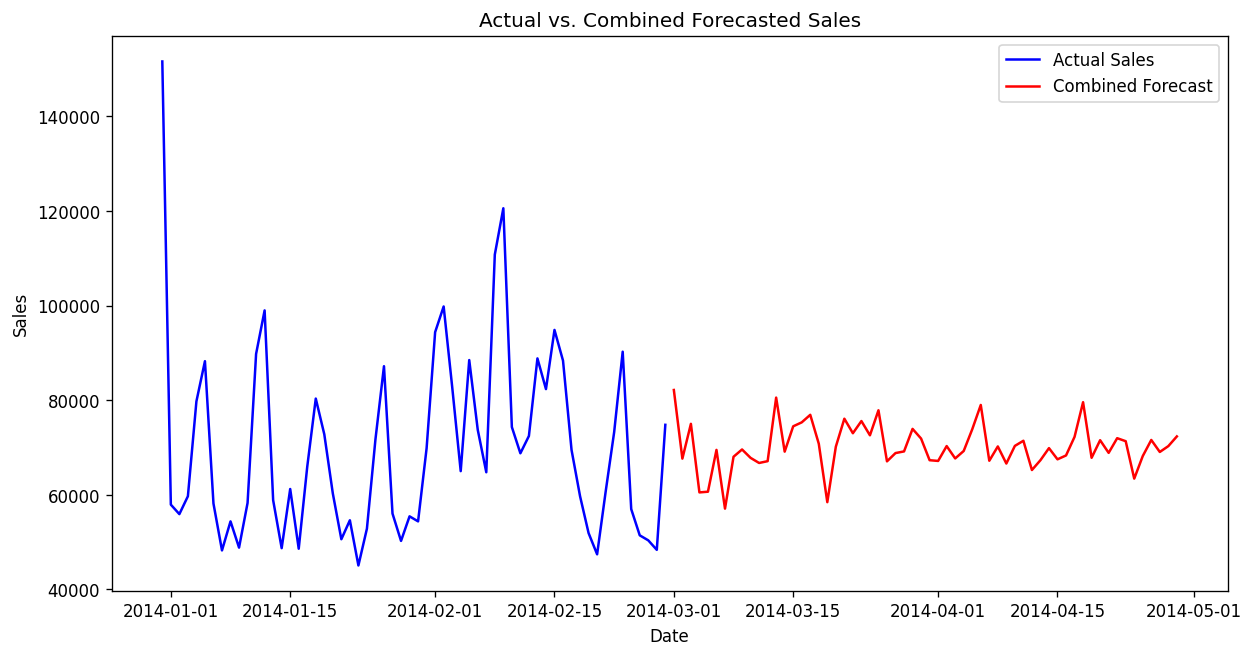

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(sales_data.index[-forecast_steps:], true_values, label='Actual Sales', color='blue')
plt.plot(forecast_dates, combined_forecast, label='Combined Forecast', color='red')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Actual vs. Combined Forecasted Sales')
plt.legend()
plt.show()